<div style="border-left: 6px solid #4C6EF5; padding: 0.2em 1.2em; background: linear-gradient(90deg,#f8f9ff, #ffffff);">

# Does the generated distribution $P_{\theta,k}$ approach the true hidden-manifold law $P_F$?

### MMD distribution-distance results — shallow masked diffusion · final run
**Presentation companion notebook** · results from `analysis_mmd_distribution_distance_corrected.ipynb` (run `full_final`: 102 rows · 3 repeats · 10 000 model + 10 000 true samples per comparison · objective `repo_uniform_t` · sampler $k{=}1$)

</div>

**What was asked** *(prof, verbatim intent)* — and where each item is answered:

| Request | Status | Section |
|---|---|---|
| "Implement some tractable (in high dimensions) metrics of distance between distributions: the one from the diffusion model and the true one" | ✅ MMD, exponential normalized-Hamming kernel | §1–2 |
| "Produce 10k samples from the diffusion models and from the true distribution" | ✅ 10 000 vs 10 000, same fixed $F$ | §1 |
| "Implement the MMD with exponential Hamming kernel, picking a few different values for the coefficient at the exponent" | ✅ $\lambda \in \{0.5, 1, 2, 4, 8, 16\}$ | §3 |
| "We should observe this value go down with alpha" | ✅ monotone decrease at every $\lambda$, every $D$, every $\gamma$ | §2–3, §6 |
| "I'm not sure it will go to zero … not sure our diffusion model has enough capacity" | ✅ confirmed: residual gap above the true-vs-true floor persists | §2, §5 |


## §0 · What the source notebook does (one screen)

For each $(D,\ \gamma{=}N/D,\ \text{repeat})$ it draws **one** feature matrix $F_{ij}\sim\mathcal N(0,1/D)$ defining the true law
$P_F:\; z\sim\mathcal N(0,I_D),\; x=\mathrm{sign}(Fz)\in\{-1,+1\}^N$, then for each sample load $\alpha=M/D$:

1. **Train** the minimal linear score model $\mathrm{logit}_i(x_t)=\sum_j W_{ij}x_{t,j}$ ($V$ frozen at 0, no bias) on $M=\alpha D$ samples, with a training budget scaled to problem size;
2. **Generate** 10 000 configurations with the sequential unmasking sampler ($k{=}1$, random order); the measured law is $P_{\theta,k=1}$ — the sampler is part of the evaluated object;
3. **Compare** against 10 000 *fresh* samples from the *same* $F$ using MMD with kernel $k_\lambda(x,y)=\exp\!\big(-\lambda\, d_H(x,y)/N\big)$, reporting biased $\mathrm{MMD}$ for plots and unbiased $\mathrm{MMD}^2$ for interpretation;
4. **Baselines per row:** true-vs-true (finite-sample floor), train-vs-true (empirical training measure), model-vs-train (memorization proxy), plus nearest-training-overlap and analytic pairwise-correlation diagnostics.

**Grid** — Experiment **A** (main): $D{=}80,\gamma{=}2$, $\alpha\in\{0.5,1,2,5,10,20,50,100\}$ · **B**: $D\in\{40,80,160\}$ at $\gamma{=}2$ · **C**: $\gamma\in\{1,2,4\}$ at $D{=}80$. Three repeats each.


In [1]:
# ── Design system ──────────────────────────────────────────────────────────
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import LogLocator, NullFormatter, ScalarFormatter

INK    = "#1B1F3B"   # near-black text
MUTED  = "#8A8FA3"   # secondary text
MODEL  = "#4C6EF5"   # indigo  — model vs true (hero)
FLOOR  = "#98A2B3"   # gray    — true vs true floor
TRAIN  = "#F59F00"   # amber   — train vs true
MTRAIN = "#0CA678"   # teal    — model vs train
ACC    = "#E03131"   # red     — annotations
LAMBDA_CMAP = plt.cm.viridis

mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 200, "figure.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 11.5,
    "axes.edgecolor": "#D5D9E4", "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.grid": True, "grid.color": "#EDF0F7", "grid.linewidth": 1.0,
    "legend.frameon": False,
})

def style(ax, xlab=r"sample load  $\alpha = M/D$", ylab=None, logx=True):
    if logx:
        ax.set_xscale("log"); ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.set_xlabel(xlab, color=MUTED)
    if ylab: ax.set_ylabel(ylab, color=MUTED)
    ax.grid(axis="x", visible=False)
    return ax

def endlabel(ax, x, y, text, color, dx=1.06, va="center", fs=10.5, weight="bold"):
    ax.annotate(text, xy=(x, y), xytext=(x*dx, y), color=color,
                fontsize=fs, fontweight=weight, va=va, ha="left",
                annotation_clip=False)

def title(ax, main, sub=None, pad=14):
    ax.set_title(main, pad=pad+ (12 if sub else 0))
    if sub:
        ax.text(0, 1.035, sub, transform=ax.transAxes, color=MUTED, fontsize=10.5)

def agg(df, gcols, vcol):
    g = df.groupby(gcols)[vcol]
    out = g.mean().reset_index(name="mean"); out["sem"] = g.sem().to_numpy()
    return out

# ── Data ───────────────────────────────────────────────────────────────────
df  = pd.read_csv("results/results_mmd_distribution_distance_corrected.csv")
ts  = pd.read_csv("results/results_mmd_time_sliced.csv")
assert (df["run_mode"] == "full_final").all() and len(df) == 102
A = df[df["is_experiment_A"] == True]
B = df[df["is_experiment_B"] == True]
Cx = df[df["is_experiment_C"] == True]
LAMBDAS = [0.5, 1, 2, 4, 8, 16]
lkey = lambda l: f"{l:g}".replace(".", "_")
print(f"Loaded {len(df)} result rows · Exp A {A.shape[0]} · B {B.shape[0]} · C {Cx.shape[0]} · time-sliced {len(ts)}")

Loaded 102 result rows · Exp A 24 · B 63 · C 54 · time-sliced 510


## §1 · The question, made measurable

Loss convergence (accepted last time) only checks **local conditional prediction**. The stronger question is about the **generated joint law**:

$$\mathrm{dist}\big(P_{\theta,k},\, P_F\big) \;\;\text{as a function of}\;\; \alpha = M/D .$$

Four MMD quantities per configuration make the answer interpretable:

<span style="color:#4C6EF5">**● Model vs True**</span> — the quantity of interest &nbsp;·&nbsp; <span style="color:#98A2B3">**● True vs True**</span> — the finite-sample floor (10k vs 10k fresh draws) &nbsp;·&nbsp; <span style="color:#F59F00">**● Train vs True**</span> — how good the raw empirical training set is &nbsp;·&nbsp; <span style="color:#0CA678">**● Model vs Train**</span> — memorization proxy.


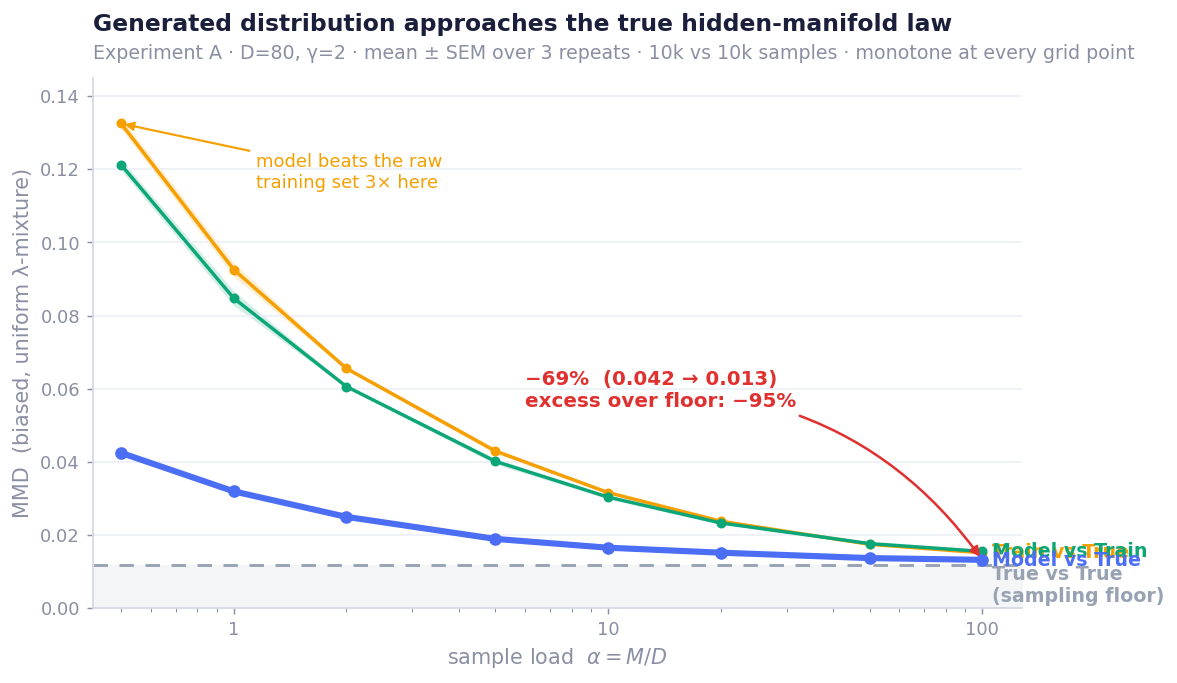

In [2]:
# ── Figure 1 · MAIN RESULT ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9.2, 5.4))
floor = A["baseline_mmd_biased_mixture"].mean()

for col, c, lab in [("train_true_mmd_biased_mixture", TRAIN,  "Train vs True"),
                    ("model_train_mmd_biased_mixture", MTRAIN, "Model vs Train"),
                    ("mmd_biased_mixture",             MODEL,  "Model vs True")]:
    g = agg(A, ["alpha"], col)
    lw = 3.4 if c == MODEL else 1.9
    ax.plot(g["alpha"], g["mean"], color=c, lw=lw, marker="o",
            ms=6 if c == MODEL else 4.5, zorder=5 if c == MODEL else 3,
            solid_capstyle="round")
    ax.fill_between(g["alpha"], g["mean"]-g["sem"], g["mean"]+g["sem"], color=c, alpha=.18, lw=0)
    endlabel(ax, g["alpha"].iloc[-1], g["mean"].iloc[-1], lab, c)

ax.axhline(floor, color=FLOOR, ls=(0, (5, 4)), lw=1.6, zorder=2)
ax.fill_between([0.4, 130], 0, floor, color=FLOOR, alpha=.10, lw=0)
endlabel(ax, 100, floor, "True vs True\n(sampling floor)", FLOOR, va="top")

g = agg(A, ["alpha"], "mmd_biased_mixture")
d0, d1 = g["mean"].iloc[0], g["mean"].iloc[-1]
ax.annotate(f"−{(1-d1/d0)*100:.0f}%  (0.042 → 0.013)\nexcess over floor: −95%",
            xy=(g["alpha"].iloc[-1], d1), xytext=(6, 0.055), color=ACC, fontsize=11, fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", color=ACC, lw=1.4,
                            connectionstyle="arc3,rad=-0.25"))
ax.annotate("model beats the raw\ntraining set 3× here", xy=(0.5, 0.1325), xytext=(1.15, 0.115),
            color=TRAIN, fontsize=10, arrowprops=dict(arrowstyle="-|>", color=TRAIN, lw=1.2))

style(ax, ylab="MMD  (biased, uniform λ-mixture)")
ax.set_xlim(0.42, 128); ax.set_ylim(0, 0.145)
title(ax, "Generated distribution approaches the true hidden-manifold law",
      "Experiment A · D=80, γ=2 · mean ± SEM over 3 repeats · 10k vs 10k samples · monotone at every grid point")
plt.tight_layout(); plt.show()

> **Takeaway 1** — Model-vs-True MMD falls **monotonically** from **0.0425** to **0.0132** (−69 %); the **excess over the true-vs-true floor shrinks by ≈95 %** (0.0307 → 0.0014).
> **Takeaway 2** — At small α the model is **much closer to $P_F$ than the raw training set** (0.042 vs 0.133 at α=0.5): the sampler *generalizes* beyond the empirical atoms rather than replaying them.


## §2 · "I'm not sure it will go to zero" — tested with the honest estimator

The unbiased $\mathrm{MMD}^2$ (zero-mean when both samples come from the same law) is the right object for this question.


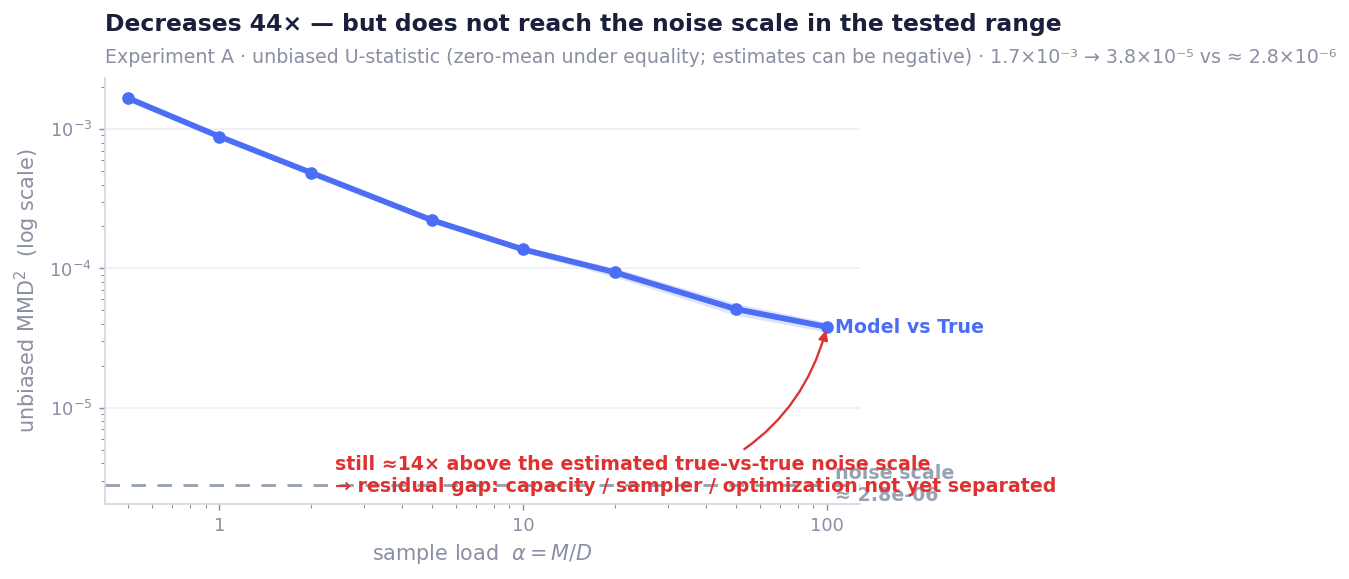

In [3]:
# ── Figure 2 · Unbiased MMD² — approaches, does NOT reach, the floor ───────
fig, ax = plt.subplots(figsize=(9.2, 4.6))
g  = agg(A, ["alpha"], "mmd2_unbiased_mixture_raw")
fl = A["baseline_mmd2_unbiased_mixture_raw"].mean()

ax.plot(g["alpha"], g["mean"], color=MODEL, lw=3.2, marker="o", ms=6, solid_capstyle="round")
ax.fill_between(g["alpha"], (g["mean"]-g["sem"]).clip(1e-7), g["mean"]+g["sem"], color=MODEL, alpha=.18, lw=0)
endlabel(ax, g["alpha"].iloc[-1], g["mean"].iloc[-1], "Model vs True", MODEL)
ax.axhline(fl, color=FLOOR, ls=(0,(5,4)), lw=1.6)
endlabel(ax, 100, fl, f"noise scale\n≈ {fl:.1e}", FLOOR)

gap = g["mean"].iloc[-1]/fl
ax.annotate(f"still ≈{gap:.0f}× above the estimated true-vs-true noise scale\n→ residual gap: capacity / sampler / optimization not yet separated",
            xy=(100, g["mean"].iloc[-1]), xytext=(2.4, 2.5e-6), color=ACC, fontsize=10.5, fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", color=ACC, lw=1.3, connectionstyle="arc3,rad=0.25"))

ax.set_yscale("log")
style(ax, ylab=r"unbiased $\mathrm{MMD}^2$  (log scale)")
ax.set_xlim(0.42, 128)
title(ax, "Decreases 44× — but does not reach the noise scale in the tested range",
      "Experiment A · unbiased U-statistic (zero-mean under equality; estimates can be negative) · 1.7×10⁻³ → 3.8×10⁻⁵ vs ≈ 2.8×10⁻⁶")
plt.tight_layout(); plt.show()

> **In one line:** the distance *does* go down with α exactly as predicted, and it does **not** reach the true-vs-true noise scale in the tested range — a ≈14× residual at α=100. This is *consistent with* the capacity concern, but capacity, sampler, optimization, and finite-size effects are not yet separated.


## §3 · "A few different values for the coefficient at the exponent"

Six kernel scales $\lambda$, shown individually — the trend is **not** an artifact of one kernel width or of the mixture summary.


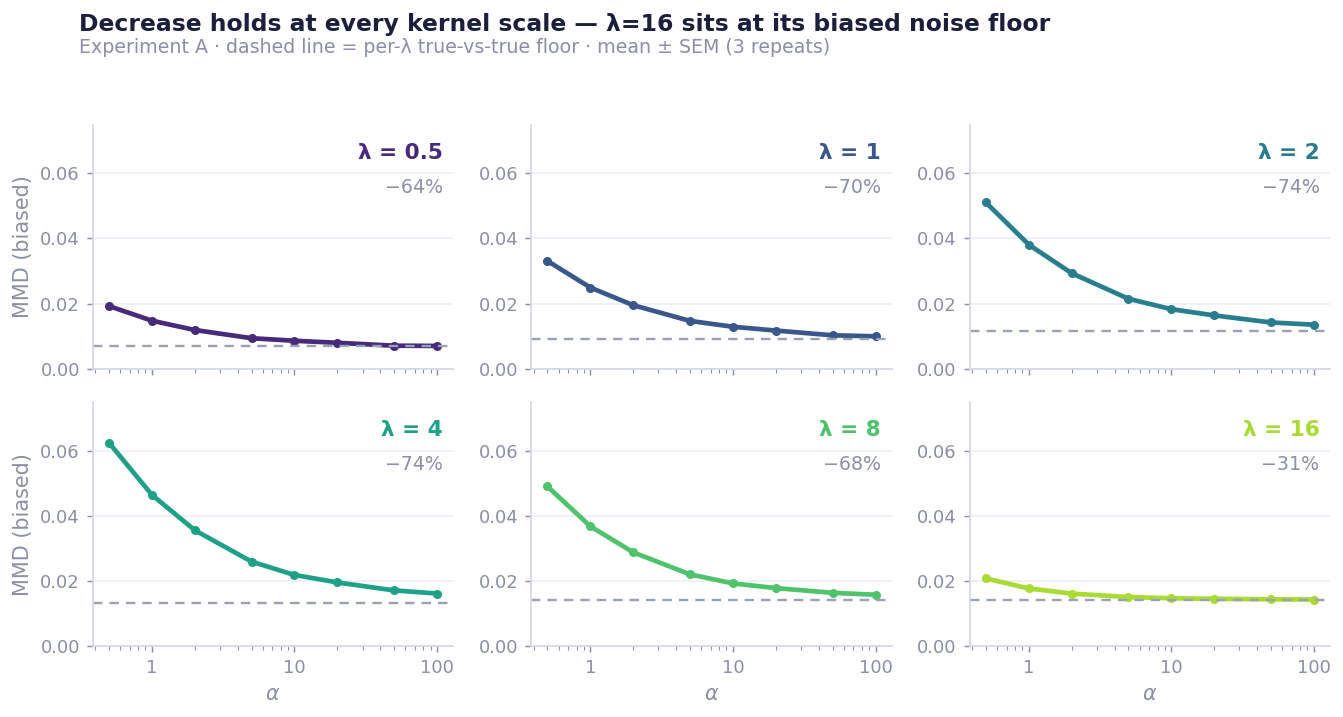

In [4]:
# ── Figure 3 · Per-λ small multiples ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(10.5, 5.6), sharex=True)
for i, (lam, ax) in enumerate(zip(LAMBDAS, axes.flat)):
    c = LAMBDA_CMAP(0.12 + 0.75*i/5)
    g  = agg(A, ["alpha"], f"mmd_biased_lambda_{lkey(lam)}")
    fl = A[f"baseline_mmd_biased_lambda_{lkey(lam)}"].mean()
    ax.plot(g["alpha"], g["mean"], color=c, lw=2.6, marker="o", ms=4, solid_capstyle="round")
    ax.fill_between(g["alpha"], g["mean"]-g["sem"], g["mean"]+g["sem"], color=c, alpha=.2, lw=0)
    ax.axhline(fl, color=FLOOR, ls=(0,(4,3)), lw=1.3)
    drop = 1 - g["mean"].iloc[-1]/g["mean"].iloc[0]
    ax.text(.97, .86, f"λ = {lam:g}", transform=ax.transAxes, ha="right",
            fontsize=12, fontweight="bold", color=c)
    ax.text(.97, .72, f"−{drop*100:.0f}%", transform=ax.transAxes, ha="right",
            fontsize=10.5, color=MUTED)
    style(ax, xlab="", logx=True); ax.set_ylim(0, 0.075)
    if i % 3 == 0: ax.set_ylabel("MMD (biased)", color=MUTED)
    if i >= 3: ax.set_xlabel(r"$\alpha$", color=MUTED)
fig.suptitle("Decrease holds at every kernel scale — λ=16 sits at its biased noise floor",
             x=0.065, ha="left", fontsize=13, fontweight="bold", color=INK)
fig.text(0.065, 0.925, "Experiment A · dashed line = per-λ true-vs-true floor · mean ± SEM (3 repeats)",
         color=MUTED, fontsize=10.5)
plt.tight_layout(rect=[0, 0, 1, 0.92]); plt.show()

> All six λ decrease (−31 % … −74 %). The **λ=16 curve improves least but sits essentially at its biased noise floor** (0.0143 vs 0.0141), so its small residual should be read through the *unbiased* statistic, not this plot. The trend is robust; per-scale magnitudes are estimator-sensitive.


## §4 · The old diagnostic, for calibration — and why it wasn't enough

BCE tests one conditional locally; the sampler composes $N$ of them. A model can look fine on average BCE and still generate the wrong joint law — which is precisely why the MMD extension was requested.


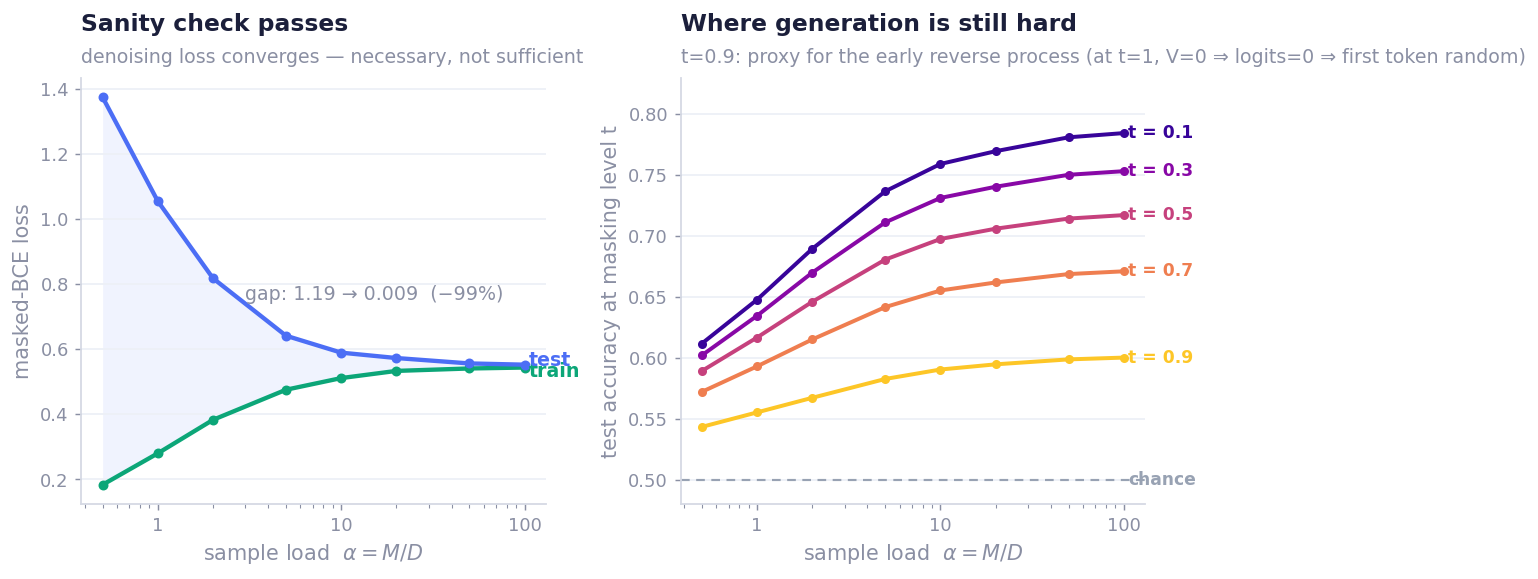

In [5]:
# ── Figure 4 · BCE sanity (left) + time-sliced bottleneck (right) ──────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6))

gtr, gte = agg(A, ["alpha"], "train_loss"), agg(A, ["alpha"], "test_loss")
ax1.plot(gtr["alpha"], gtr["mean"], color=MTRAIN, lw=2.4, marker="o", ms=4.5)
ax1.plot(gte["alpha"], gte["mean"], color=MODEL,  lw=2.4, marker="o", ms=4.5)
ax1.fill_between(gte["alpha"], gtr["mean"], gte["mean"], color=MODEL, alpha=.08, lw=0)
endlabel(ax1, gtr["alpha"].iloc[-1], gtr["mean"].iloc[-1]-0.012, "train", MTRAIN)
endlabel(ax1, gte["alpha"].iloc[-1], gte["mean"].iloc[-1]+0.012, "test",  MODEL)
ax1.annotate("gap: 1.19 → 0.009  (−99%)", xy=(3, 0.75), color=MUTED, fontsize=10.5)
style(ax1, ylab="masked-BCE loss")
title(ax1, "Sanity check passes", "denoising loss converges — necessary, not sufficient")

alphas = sorted(ts[(ts.D==80)&(ts.gamma==2)]["alpha"].unique())
tsA = ts[(ts.D==80)&(ts.gamma==2)]
for j, tv in enumerate([0.1, 0.3, 0.5, 0.7, 0.9]):
    c = plt.cm.plasma(0.08 + 0.8*j/4)
    g = tsA[tsA.t_val==tv].groupby("alpha")["test_acc_t"].mean()
    ax2.plot(g.index, g.values, color=c, lw=2.2, marker="o", ms=4)
    endlabel(ax2, g.index[-1], g.values[-1], f"t = {tv}", c, fs=9.5)
ax2.axhline(0.5, color=FLOOR, ls=(0,(4,3)), lw=1.2)
endlabel(ax2, 100, 0.5, "chance", FLOOR, fs=9.5)
style(ax2, ylab="test accuracy at masking level t")
ax2.set_ylim(0.48, 0.83)
title(ax2, "Where generation is still hard",
      "t=0.9: proxy for the early reverse process (at t=1, V=0 ⇒ logits=0 ⇒ first token random)")
plt.tight_layout(); plt.show()

> **Left:** the accepted loss-convergence result reproduces exactly. **Right:** the time-sliced diagnostic localizes the difficulty — accuracy at $t{=}0.9$ (almost everything masked, the regime every generated sample must pass through first) saturates at ≈0.60 while $t{=}0.1$ reaches ≈0.785. The early trajectory of generation is the bottleneck.


## §5 · What the model is actually doing: from memory-like to distribution-like

Two independent diagnostics interpret *why* the MMD falls — and where it stalls.


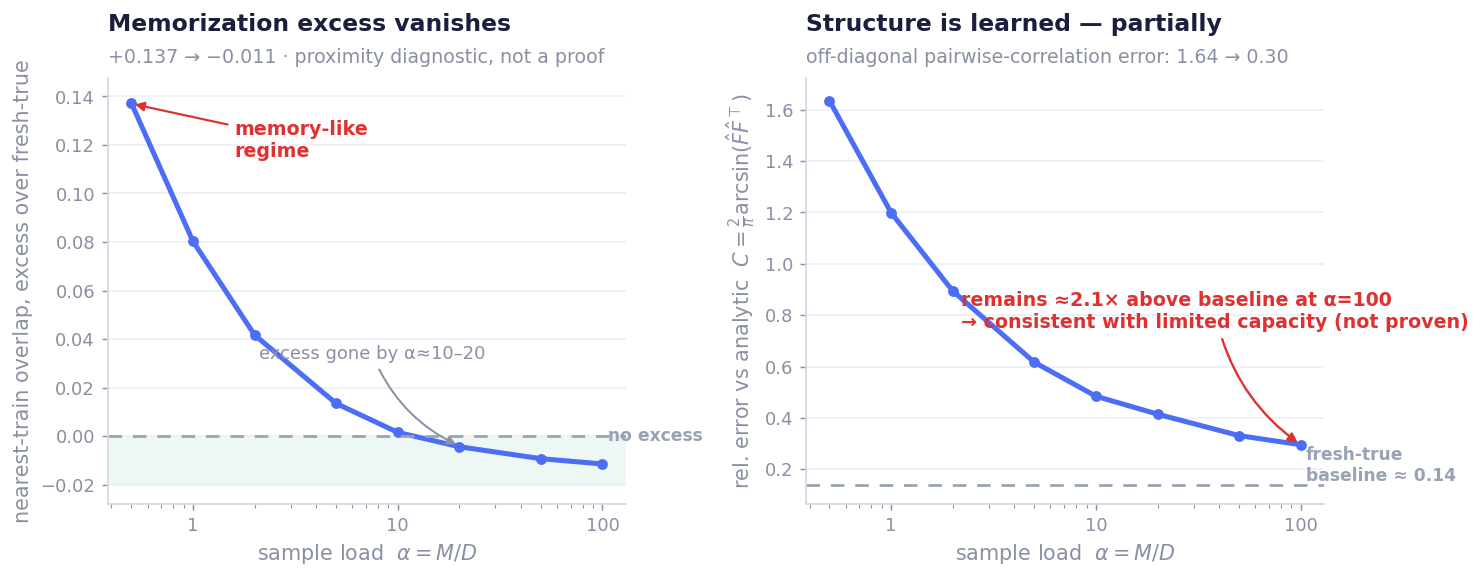

In [6]:
# ── Figure 5 · Memorization excess (left) + correlation recovery (right) ───
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6))

g = agg(A, ["alpha"], "nearest_train_q1_excess_over_true")
ax1.axhspan(-0.02, 0, color=MTRAIN, alpha=.07, lw=0)
ax1.plot(g["alpha"], g["mean"], color=MODEL, lw=2.8, marker="o", ms=5, solid_capstyle="round")
ax1.fill_between(g["alpha"], g["mean"]-g["sem"], g["mean"]+g["sem"], color=MODEL, alpha=.18, lw=0)
ax1.axhline(0, color=FLOOR, ls=(0,(5,4)), lw=1.5)
endlabel(ax1, 100, 0, "no excess", FLOOR, fs=9.5)
ax1.annotate("memory-like\nregime", xy=(0.5, 0.137), xytext=(1.6, 0.115), color=ACC, fontsize=10.5,
             fontweight="bold", arrowprops=dict(arrowstyle="-|>", color=ACC, lw=1.2))
ax1.annotate("excess gone by α≈10–20", xy=(20, -0.004), xytext=(2.1, 0.032), color=MUTED, fontsize=10,
             arrowprops=dict(arrowstyle="-|>", color=MUTED, lw=1.1, connectionstyle="arc3,rad=0.2"))
style(ax1, ylab="nearest-train overlap, excess over fresh-true")
title(ax1, "Memorization excess vanishes",
      "+0.137 → −0.011 · proximity diagnostic, not a proof")

g  = agg(A, ["alpha"], "corr_relerr_model_true")
bl = A["corr_relerr_fresh_true"].mean()
ax2.plot(g["alpha"], g["mean"], color=MODEL, lw=2.8, marker="o", ms=5, solid_capstyle="round")
ax2.fill_between(g["alpha"], g["mean"]-g["sem"], g["mean"]+g["sem"], color=MODEL, alpha=.18, lw=0)
ax2.axhline(bl, color=FLOOR, ls=(0,(5,4)), lw=1.5)
endlabel(ax2, 100, bl, f"fresh-true\nbaseline ≈ {bl:.2f}", FLOOR, va="bottom", fs=9.5)
ax2.annotate("remains ≈2.1× above baseline at α=100\n→ consistent with limited capacity (not proven)", xy=(100, g["mean"].iloc[-1]),
             xytext=(2.2, 0.75), color=ACC, fontsize=10.5, fontweight="bold",
             arrowprops=dict(arrowstyle="-|>", color=ACC, lw=1.3, connectionstyle="arc3,rad=0.2"))
style(ax2, ylab="rel. error vs analytic  $C=\\frac{2}{\\pi}\\arcsin(\\hat F\\hat F^\\top)$")
title(ax2, "Structure is learned — partially",
      "off-diagonal pairwise-correlation error: 1.64 → 0.30")
plt.tight_layout(); plt.show()

> **Left** — at low α, generated samples sit abnormally close to training points; by α≈10–20 that excess is gone while MMD keeps improving: the model moves from a **memory-like** to a **distribution-like** regime.
> **Right** — against the *analytic* correlation matrix of $P_F$ (arcsine law, zero sampling error on the target side), the model recovers most of the $F$-induced structure but **remains ≈2.1× above** the fresh-true baseline at α=100 (and is still decreasing slowly). This is quantitative evidence *consistent with* limited capacity of the W-only model — not yet proof.


## §6 · Robustness: the trend is not a coincidence of one setting


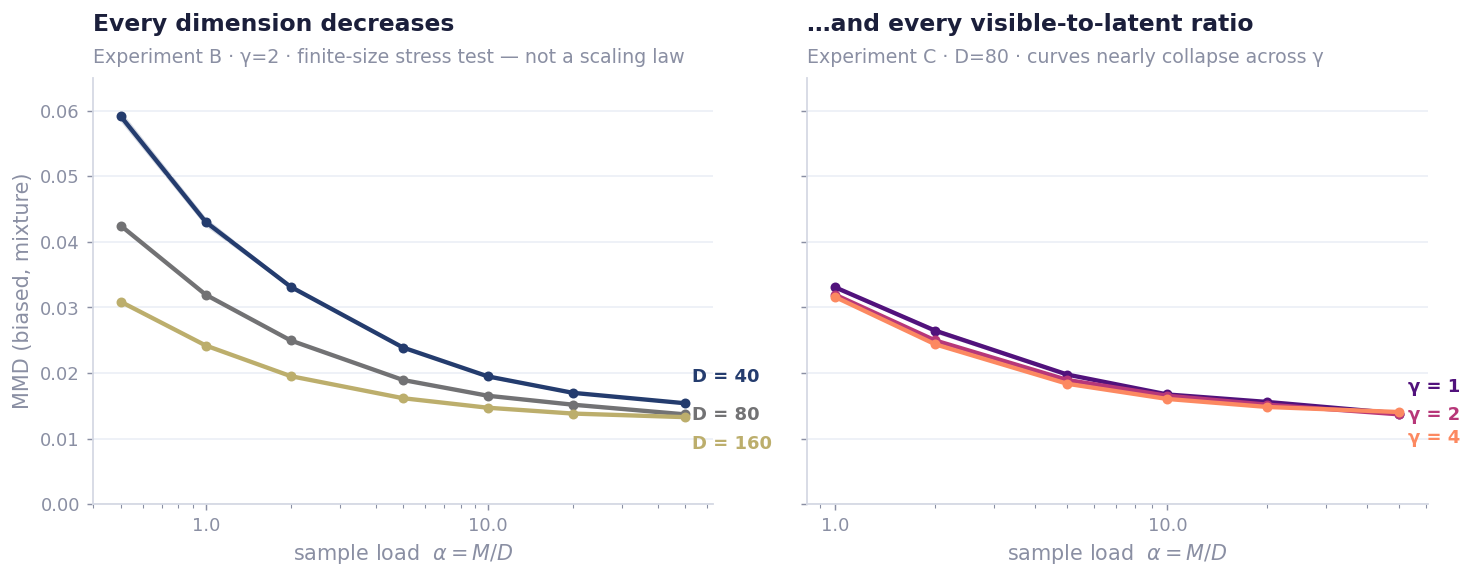

In [7]:
# ── Figure 6 · D-sweep and γ-sweep ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=True)

dy_D = {40: 0.004, 80: 0.0, 160: -0.004}
for i, D in enumerate([40, 80, 160]):
    c = plt.cm.cividis(0.15 + 0.6*i/2)
    sub = B[B.D==D]; g = agg(sub, ["alpha"], "mmd_biased_mixture")
    ax1.plot(g["alpha"], g["mean"], color=c, lw=2.4, marker="o", ms=4.5)
    ax1.fill_between(g["alpha"], g["mean"]-g["sem"], g["mean"]+g["sem"], color=c, alpha=.18, lw=0)
    endlabel(ax1, g["alpha"].iloc[-1], g["mean"].iloc[-1] + dy_D[D], f"D = {D}", c, fs=10)
style(ax1, ylab="MMD (biased, mixture)")
title(ax1, "Every dimension decreases", "Experiment B · γ=2 · finite-size stress test — not a scaling law")

dy_g = {1.0: 0.004, 2.0: 0.0, 4.0: -0.004}
for i, gm in enumerate([1.0, 2.0, 4.0]):
    c = plt.cm.magma(0.25 + 0.5*i/2)
    sub = Cx[Cx.gamma==gm]; g = agg(sub, ["alpha"], "mmd_biased_mixture")
    ax2.plot(g["alpha"], g["mean"], color=c, lw=2.4, marker="o", ms=4.5)
    ax2.fill_between(g["alpha"], g["mean"]-g["sem"], g["mean"]+g["sem"], color=c, alpha=.18, lw=0)
    endlabel(ax2, g["alpha"].iloc[-1], g["mean"].iloc[-1] + dy_g[gm], f"γ = {gm:g}", c, fs=10)
style(ax2)
title(ax2, "…and every visible-to-latent ratio", "Experiment C · D=80 · curves nearly collapse across γ")
ax1.set_ylim(0, 0.065)
plt.tight_layout(); plt.show()

> Same qualitative behavior at every $D$ and every $\gamma$; the γ-curves nearly collapse. **Stated caveat** (before anyone raises it): the D-sweep changes $N$, $M$, parameter count, and optimization budget together — it demonstrates robustness, not a thermodynamic limit.


---
## Verdict

<div style="border:1px solid #E3E7F2; border-radius:10px; padding:1em 1.4em; background:#FAFBFF;">

**Does $P_{\theta,k}$ approach $P_F$? Yes — measurably, monotonically, robustly. Does it match it in the tested regime? Not yet.**

1. **Requested diagnostic delivered:** MMD, exponential Hamming kernel, six exponent coefficients, 10k vs 10k samples.
2. **Predicted trend confirmed:** Model-vs-True MMD ↓ monotonically with α at every λ, every D, every γ (0.0425 → 0.0132; excess over floor −95 %).
3. **Residual gap observed:** unbiased MMD² remains ≈14× above the true-vs-true noise scale; correlation error remains ≈2.1× above the fresh-sample baseline — consistent with the capacity concern, but capacity / sampler / optimization / finite-size are not yet separated.
4. **Mechanism:** memorization excess at low α vanishes by α≈10–20 — a memory-to-generalization transition visible in the samples themselves.

</div>

**Honest limitations** · 3 repeats, no bootstrap CIs / permutation tests on MMD · sampler $k{=}1$ only (the sampler is part of the measured object) · $V{=}0$, bias-free by symmetry argument, ablation pending · D-sweep confounded with budget · optimization quality audited only via logged convergence ratios.

**Next steps** · trainable-$V$ and bias ablations · sampler $k$-sweep · bootstrap error bands · isolate capacity vs optimization in the residual gap · theory: can any $W$-only conditional family represent $P_F$?
